Dataset Shape: (1143, 11)
    ad_id  xyz_campaign_id  fb_campaign_id    age gender  interest  \
0  708746              916          103916  30-34      M        15   
1  708749              916          103917  30-34      M        16   
2  708771              916          103920  30-34      M        20   
3  708815              916          103928  30-34      M        28   
4  708818              916          103928  30-34      M        28   

   Impressions  Clicks  Spent  Total_Conversion  Approved_Conversion  
0         7350       1   1.43                 2                    1  
1        17861       2   1.82                 2                    0  
2          693       0   0.00                 1                    0  
3         4259       1   1.25                 1                    0  
4         4133       1   1.29                 1                    1  

Ad-level Metrics:
     ad_id       CTR   CPC  Conversion Rate       ROI
0  708746  0.000136  1.43              2.0  1.398601
1

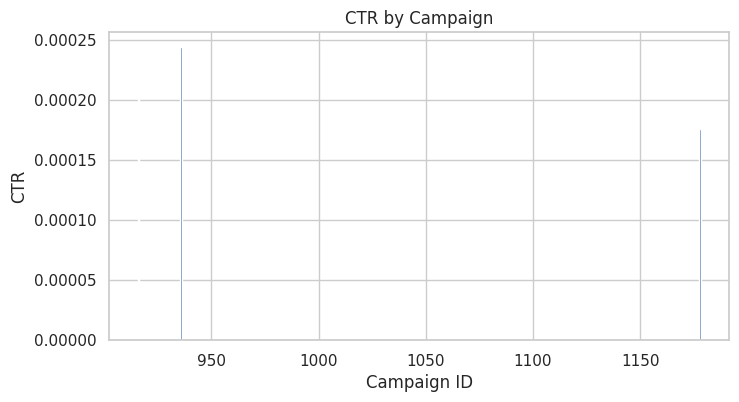

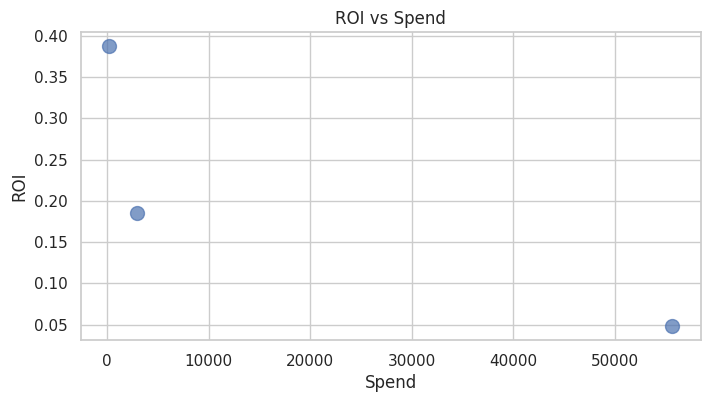


👥 Audience Segmentation:
      age gender  Impressions  Clicks         Spent  Total_Conversion  \
0  30-34      F     31571576    5099   7611.479995               619   
1  30-34      M     36421443    4384   7640.919991               812   
2  35-39      F     21439505    4161   6061.349992               304   
3  35-39      M     20665139    2933   5051.080003               322   
4  40-44      F     23396175    5177   7396.579984               322   
5  40-44      M     16208132    2559   4193.149997               201   
6  45-49      F     38455591    9441  13433.209993               399   
7  45-49      M     25277267    4411   7317.460004               285   

        CTR       CPC  Conversion Rate       ROI  
0  0.000162  1.492740         0.121396  0.081325  
1  0.000120  1.742911         0.185219  0.106270  
2  0.000194  1.456705         0.073059  0.050154  
3  0.000142  1.722155         0.109785  0.063749  
4  0.000221  1.428739         0.062198  0.043534  
5  0.000158  1.638

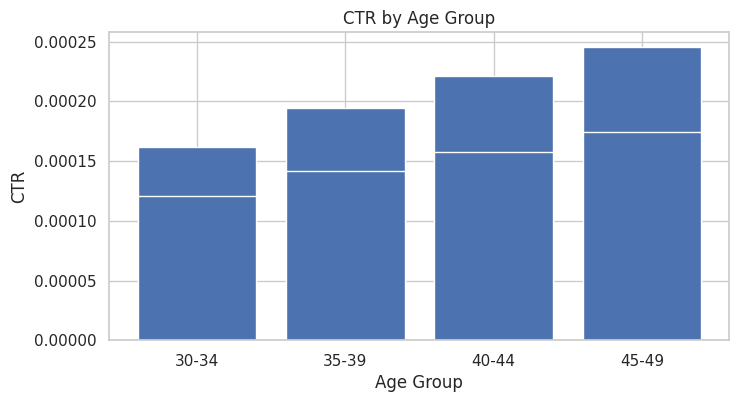


📈 Forecast Results:
    xyz_campaign_id         Spent       ROI  Expected_Spend  \
0              916    149.710001  0.387416      179.652001   
1              936   2893.369999  0.185597     3472.043999   
2             1178  55662.149959  0.047950    66794.579950   

   Forecast_Conversions  
0                  69.6  
1                 644.4  
2                3202.8  


In [8]:
# 📊 Ad Campaign Performance Optimization Project
# Dataset: KAG_conversion_data.csv (from Kaggle)

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# STEP 1: Load dataset
# ------------------------------
df = pd.read_csv("KAG_conversion_data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ------------------------------
# STEP 2: Create metrics at Ad-level
# ------------------------------
df['CTR'] = df['Clicks'] / df['Impressions'].replace(0, 1)
df['CPC'] = df['Spent'] / df['Clicks'].replace(0, 1)
df['Conversion Rate'] = df['Total_Conversion'] / df['Clicks'].replace(0, 1)
df['ROI'] = df['Total_Conversion'] / df['Spent'].replace(0, 1)

print("\nAd-level Metrics:\n", df[['ad_id','CTR','CPC','Conversion Rate','ROI']].head())

# ------------------------------
# STEP 3: Aggregate by Campaign
# ------------------------------
campaign_perf = df.groupby('xyz_campaign_id').agg({
    'Impressions':'sum',
    'Clicks':'sum',
    'Spent':'sum',
    'Total_Conversion':'sum'
}).reset_index()

campaign_perf['CTR'] = campaign_perf['Clicks'] / campaign_perf['Impressions']
campaign_perf['CPC'] = campaign_perf['Spent'] / campaign_perf['Clicks'].replace(0, 1)
campaign_perf['Conversion Rate'] = campaign_perf['Total_Conversion'] / campaign_perf['Clicks'].replace(0, 1)
campaign_perf['ROI'] = campaign_perf['Total_Conversion'] / campaign_perf['Spent'].replace(0, 1)

print("\n📊 Campaign-Level Summary:\n", campaign_perf)

# ------------------------------
# STEP 4: Visualizations
# ------------------------------

# CTR by Campaign
plt.figure(figsize=(8,4))
plt.bar(campaign_perf['xyz_campaign_id'], campaign_perf['CTR'])
plt.xlabel("Campaign ID")
plt.ylabel("CTR")
plt.title("CTR by Campaign")
plt.show()

# ROI vs Spend
plt.figure(figsize=(8,4))
plt.scatter(campaign_perf['Spent'], campaign_perf['ROI'], s=100, alpha=0.7)
plt.xlabel("Spend")
plt.ylabel("ROI")
plt.title("ROI vs Spend")
plt.show()

# ------------------------------
# STEP 5: Audience Segmentation (Age x Gender)
# ------------------------------
segmentation = df.groupby(['age','gender']).agg({
    'Impressions':'sum',
    'Clicks':'sum',
    'Spent':'sum',
    'Total_Conversion':'sum'
}).reset_index()

segmentation['CTR'] = segmentation['Clicks'] / segmentation['Impressions'].replace(0, 1)
segmentation['CPC'] = segmentation['Spent'] / segmentation['Clicks'].replace(0, 1)
segmentation['Conversion Rate'] = segmentation['Total_Conversion'] / segmentation['Clicks'].replace(0, 1)
segmentation['ROI'] = segmentation['Total_Conversion'] / segmentation['Spent'].replace(0, 1)

print("\n👥 Audience Segmentation:\n", segmentation)

# CTR by Age Group
plt.figure(figsize=(8,4))
plt.bar(segmentation['age'], segmentation['CTR'])
plt.xlabel("Age Group")
plt.ylabel("CTR")
plt.title("CTR by Age Group")
plt.show()

# ------------------------------
# STEP 6: Simple Forecast (Budget Pacing Simulation)
# ------------------------------
campaign_perf['Expected_Spend'] = campaign_perf['Spent'] * 1.2  # simulate +20% budget
campaign_perf['Forecast_Conversions'] = campaign_perf['Conversion Rate'] * (campaign_perf['Clicks']*1.2)

print("\n📈 Forecast Results:\n", campaign_perf[['xyz_campaign_id','Spent','ROI','Expected_Spend','Forecast_Conversions']])
